In [1]:
import pyro
import pyro.distributions as dist
import torch
import torch.nn.functional as F
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
from pyro import poutine
from pyro.distributions import constraints
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.infer import config_enumerate
import tqdm
import numpy as np
import seaborn
import matplotlib.pyplot as plt
import scvi
import scanpy as sc
import anndata
import pandas as pd
from collections import defaultdict
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print("GPU is available")
    print("Number of GPUs:", torch.cuda.device_count())
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available")

import antipode

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU is available
Number of GPUs: 1
GPU Name: NVIDIA A100-PCIE-40GB


In [121]:
# Set random seed for reproducibility
pyro.set_rng_seed(0)

# Define constants
n_latent = 6
n_var = 250
n_components = 10
n_datapoints = 50000
locs_range = 2
batch_size = 32

In [313]:
from torch.distributions import constraints
from torch.distributions.normal import Normal
from torch.distributions.transformed_distribution import TransformedDistribution
from torch.distributions.transforms import ExpTransform
from pyro.distributions.torch_distribution import TorchDistributionMixin
from pyro.distributions.util import broadcast_shape, sum_rightmost
from pyro.ops.special import log_binomial

import torch
from torch.distributions import constraints, Normal, Distribution
from torch.distributions.utils import broadcast_all

from torch.distributions.exp_family import ExponentialFamily

def log_standard_normal_cdf(x):
    return -F.softplus(np.log(2) - x*np.sqrt(2*np.pi))

class TorchFlooredLogNormal(ExponentialFamily):
    
    def __init__(self, loc, scale, validate_args=None):
        loc , scale=broadcast_all(loc, scale)
        batch_shape = loc.size()
        super(TorchFlooredLogNormal, self).__init__(batch_shape, validate_args=validate_args)
        self.loc, self.scale = loc,scale
        arg_constraints = {"loc": constraints.real, "scale": constraints.positive}
        support = constraints.nonnegative
        has_rsample = False
        _mean_carrier_measure = 0
        self.base_dist=Normal(self.loc, self.scale)

    def expand(self, batch_shape, _instance=None):
        new = self._get_checked_instance(TorchFlooredLogNormal, _instance)
        batch_shape = torch.Size(batch_shape)
        new.loc = self.loc.expand(batch_shape)
        new.scale = self.scale.expand(batch_shape)
        super(TorchFlooredLogNormal, new).__init__(batch_shape, validate_args=False)
        new._validate_args = self._validate_args
        return new
    
    def sample(self, sample_shape=torch.Size()):
        shape = self._extended_shape(sample_shape)
        normal_sample = torch.normal(self.loc.expand(shape), self.scale.expand(shape))
        return torch.floor(torch.exp(normal_sample))
    
    def log_prob(self, value):
        if self._validate_args:
            self._validate_sample(value)
        value = value.to(self.loc.dtype)
        #normal = self.base_dist
        normal = Normal(self.loc, self.scale)
        cdf1 = normal.cdf((value + 1.).log())
        cdf2 = normal.cdf(value.log())
        cdf_diff = cdf1 - cdf2
        return torch.clamp(cdf_diff,min=torch.finfo().tiny,max=1.).log()

    @property
    def mean(self):#TODO
        return (self.loc + self.scale.pow(2) / 2).exp()

    @property
    def mode(self):#TODO
        return (self.loc - self.scale.square()).exp()

    @property
    def variance(self):#TODO
        scale_sq = self.scale.pow(2)
        return scale_sq.expm1() * (2 * self.loc + scale_sq).exp()

    def entropy(self):#TODO
        return self.base_dist.entropy() + self.loc


class FlooredLogNormal(TorchFlooredLogNormal, TorchDistributionMixin):
    def __init__(self, loc, scale, validate_args=None):
        super(FlooredLogNormal, self).__init__(loc, scale, validate_args=validate_args)

    def expand(self, batch_shape, _instance=None):
        new = self._get_checked_instance(FlooredLogNormal, _instance)
        return super(FlooredLogNormal, self).expand(batch_shape, _instance=new)



In [314]:
grads=defaultdict(list)

import pyro
import pyro.ops.jit
from pyro.distributions.util import is_identically_zero
from pyro.infer.elbo import ELBO
from pyro.infer.enum import get_importance_trace
from pyro.infer.util import (
    MultiFrameTensor,
    get_plate_stacks,
    is_validation_enabled,
    torch_item,
)
from pyro.util import check_if_enumerated, warn_if_nan

class SafeSVI(pyro.infer.abstract_infer.TracePosterior):
    '''A version of pyro.infer.SVI that skips steps with loss more than X sigma from the running mean loss'''
    def __init__(
        self,
        model,
        guide,
        optim,
        loss,
        loss_and_grads=None,
        clip_std_multiplier=6.0,
        window_size=1000,  # Default window size of 300
        **kwargs
    ):
        super().__init__(**kwargs)
        self.model = model
        self.guide = guide
        self.optim = optim
        self.record = False
        self.clip_std_multiplier = clip_std_multiplier
        self.window_size = window_size
        self.losses = []  # Store recent losses to calculate running stats

        if not isinstance(optim, pyro.optim.PyroOptim):
            raise ValueError("Optimizer should be an instance of pyro.optim.PyroOptim class.")

        if isinstance(loss, ELBO):
            self.loss = loss.loss
            self.loss_and_grads = loss.loss_and_grads
        else:
            if loss_and_grads is None:
                def _loss_and_grads(*args, **kwargs):
                    loss_val = loss(*args, **kwargs)
                    if getattr(loss_val, "requires_grad", False):
                        loss_val.backward(retain_graph=True)
                    return loss_val
                self.loss_and_grads = _loss_and_grads
            else:
                self.loss_and_grads = loss_and_grads

    def _traces(self, *args, **kwargs):
        for i in range(self.num_samples):
            guide_trace = poutine.trace(self.guide).get_trace(*args, **kwargs)
            model_trace = poutine.trace(
                poutine.replay(self.model, trace=guide_trace)
            ).get_trace(*args, **kwargs)
            yield model_trace, 1.0

    def evaluate_loss(self, *args, **kwargs):
        with torch.no_grad():
            loss = self.loss(self.model, self.guide, *args, **kwargs)
            return torch_item(loss)

    def step(self, *args, **kwargs):
        # Compute loss and gradients
        with poutine.trace(param_only=True) as param_capture:
            loss = self.loss_and_grads(self.model, self.guide, *args, **kwargs)
    
        loss_val = torch_item(loss)
        self.losses.append(loss_val)
        # Keep only the last `window_size` losses
        if len(self.losses) > self.window_size:
            self.losses.pop(0)
        # Extract params early to ensure they are defined for later use
        params = set(site["value"].unconstrained() for site in param_capture.trace.nodes.values())
        
        # Calculate running mean and std only if we have enough data
        if len(self.losses) >= self.window_size:
            running_mean = np.mean(self.losses)
            running_std = np.std(self.losses)
            #print(loss, running_mean,running_std)
            if ((loss > running_mean-running_std*self.clip_std_multiplier) and (loss < running_mean+running_std*self.clip_std_multiplier)):
                # Perform optimization step
                self.optim(params)
            else:
                print('STEP SKIPPED')
        else:
            self.optim(params)
        
        if self.record:
            for name, value in pyro.get_param_store().named_parameters():
                grads[name].append(value.grad.detach().cpu().numpy())
        
        # Zero gradients
        pyro.infer.util.zero_grads(params)
    
        return loss_val

In [315]:
class ToyModel(torch.nn.Module):
    def __init__(self, n_latent=5, n_var=10, n_components=3):
        super(ToyModel, self).__init__()
        pyro.clear_param_store()
        self.n_latent = n_latent
        self.n_var = n_var
        self.n_components = n_components
        self.scale=1e-4
        # Assuming ZLEncoder and SimpleFFNN are defined elsewhere and imported
        self.encoder = antipode.train_utils.ZLEncoder(num_var=self.n_var, hidden_dims=[1000, 1000, 1000], outputs=[(self.n_latent, None), (self.n_latent, torch.nn.functional.softplus)])
        self.classifier = antipode.train_utils.SimpleFFNN(in_dim=self.n_latent, hidden_dims=[1000, 1000, 1000], out_dim=self.n_components)

    @config_enumerate
    def model(self, data=None):
        pyro.module("toy", self)
        device = data.device
        
        with poutine.scale(scale=self.scale):
            with pyro.plate('batch', data.shape[0]):
                l = data.sum(-1).unsqueeze(-1) + 1.
                
                # Ensure parameters are leaf tensors
                locs = pyro.param('locs', 0.1 * torch.randn(self.n_components, self.n_latent, device=device))
                scales = pyro.param('scales', torch.ones(self.n_components, self.n_latent, device=device), constraint=constraints.positive)
                transform_matrix = pyro.param('transform_matrix', 0.1 * torch.rand(self.n_latent, self.n_var, device=device))

                intercept = pyro.param('intercept', torch.zeros(self.n_components, self.n_var, device=device))
                total_counts = pyro.param('total_counts', 10 * torch.ones(self.n_var, device=device), constraint=constraints.positive)
                
                z = pyro.sample('z', dist.Categorical(logits=torch.ones(self.n_components, device=device),validate_args=True), infer={"enumerate": "parallel"})
                latent = pyro.sample('latent', dist.Normal(locs[z], scales[z]).to_event(1))
                out_mu = latent @ transform_matrix + intercept[z]
                #softmax_shift = pyro.param('softmax_shift', out_mu.detach().exp().sum(-1).mean().log())
                #logits = out_mu - total_counts.log() + l.log() - softmax_shift
                #logits = torch.nn.functional.log_softmax(out_mu,dim=-1) - total_counts.log() + l.log() #- softmax_shift
                #pyro.sample('obs', dist.NegativeBinomial(total_count=total_counts, logits=logits,validate_args=False).to_event(1), obs=data+1e-6)
                #b_dist = dist.Bernoulli(probs=1-((total_counts * torch.nn.functional.logsigmoid(-logits))).exp()).to_event(1)
                #b_out=pyro.sample("b",b_dist, obs=(data>0.).float())
                #pyro.sample('obs', dist.Normal(loc=logits,scale=total_counts,validate_args=False).to_event(1), obs=(data+1e-9).log())#Reverses the gradient trends, but doesn't reconstruct well
                norm_mu=torch.nn.functional.log_softmax(out_mu,dim=-1) + l.log() - (total_counts**2)/2
                print(FlooredLogNormal(loc=norm_mu,scale=total_counts,validate_args=False).log_prob(data.float()).min())
                pyro.sample('obs', FlooredLogNormal(loc=norm_mu,scale=total_counts,validate_args=True).to_event(1), obs=data)


    def guide(self, data=None):
        pyro.module("toy", self)
        device = data.device
        with poutine.scale(scale=self.scale):
            with pyro.plate('batch', data.shape[0]):
                locs_mu, locs_std = self.encoder(data)
                latent = pyro.sample('latent', dist.Normal(locs_mu, locs_std,validate_args=True).to_event(1))
                weights_probs = pyro.sample('z', dist.Categorical(logits=self.classifier(latent),validate_args=True), infer={"enumerate": "parallel"})

In [316]:
# Generate synthetic data
def generate_synthetic_data(n_datapoints=5000,locs_range=2.):
    weights = torch.ones(n_components) / n_components
    locs = torch.randn(n_components, n_latent) * locs_range
    scales = torch.ones(n_components, n_latent) * 0.5
    transform_matrix = 1.*torch.randn(n_latent, n_var)
    intercept = 4*torch.rand(n_components, n_var)-2.
    overall_intercept = 16*torch.rand(n_var)-8.
    data = []
    true_clusters=[]
    true_latent=[]
    for _ in range(n_datapoints):
        l = 7 + 2*torch.rand(1)
        z = torch.multinomial(weights, 1).item()
        true_clusters.append(z)
        latent = torch.normal(locs[z], scales[z])
        true_latent.append(latent)
        out_mu = latent @ transform_matrix + intercept[z] + overall_intercept
        total_counts = torch.tensor(25.0)
        logits = (torch.softmax(out_mu,dim=-1)*l.exp()).log() - torch.log(total_counts) 
        counts = dist.NegativeBinomial(total_counts, logits=logits).sample()
        data.append(counts)
    
    return torch.stack(data),{'latent':true_latent,'clusters':true_clusters,'weights':weights,'locs':locs,'scales':scales,'intercept':intercept}

# Generate synthetic data
# data, true_params = generate_synthetic_data(n_datapoints=n_datapoints)
# adata=anndata.AnnData(X=data.cpu().numpy(),obs=pd.DataFrame([str(x) for x in true_params['clusters']],columns=['true_clusters']))
# adata.obsm['true_latents']=np.stack(true_params['latent'],axis=0)

In [317]:
(data>0).sum(0)

tensor([  101,   874, 11320,     1,    20,     5,  8787,     3, 12216,  1567,
         6449, 16197,  8169,  7784,     0,    14,     4,  2071,   149,    29,
          231,     0, 19123,   123, 12840,  4279,  2873, 10509,    26,   333,
         2446,     2,     5,    35,     1, 12330,     1,    36,     5,   408,
           95,     1,  7574,    64,     8,   627,    23,    12,    80,  7223,
        11945,  5175,    94, 14370,    17,   360,    17,     0,     9,     0,
         1749,    10,  5368, 11306,  8678,     0,    11,  3334,  7299,  6258,
          321,     3,     3,     7, 22228,     0,  8919,  7334,     0,  6100,
            8, 10620, 15579,   809,  5141,  5109,    35,     0,   525,    68,
        13085, 19631,  6011,     0,   578,     0,   401,    20, 10343,     8,
            2,     0,  1456,   101,    44,     0,  8707, 12014,  8850,  2892,
          739,     7,     1,    14,     0,    63,  4746,  1833,  8298,     3,
          132,  7251,    64,     0,   112,  5389,     1,    13, 

In [318]:
# seaborn.histplot(np.log(data.flatten()+0.1))

In [319]:
# seaborn.histplot(data.sum(1).flatten(),bins=10)

In [320]:
toy_model = ToyModel(n_latent = n_latent+5,n_var = n_var,n_components = n_components+5)
toy_model.to(device)
grads=defaultdict(list)

# SVI setup
adam_params = {"lr": 0.005}
optimizer = Adam(adam_params)
svi = SafeSVI(toy_model.model, toy_model.guide, optimizer, loss=pyro.infer.TraceEnum_ELBO())

# Training loop
num_iterations = 30
losses = []

In [321]:
for i in tqdm.tqdm(range(num_iterations)):
    svi.record=False
    if i==num_iterations-1:
        svi.record=True
    loss = 0
    for j in range(0, n_datapoints, batch_size):
        batch = data[j:j+batch_size]
        loss = svi.step(batch.int().to(device))
        losses.append(loss)
    print(f"Iteration {i} : Loss {loss}")

print("Training complete.")

  0%|          | 0/30 [00:00<?, ?it/s]


tensor(-87.3365, device='cuda:0', grad_fn=<MinBackward1>)
tensor(-87.3365, device='cuda:0', grad_fn=<MinBackward1>)


ValueError: Expected parameter loc (Tensor of shape (15, 32, 250)) of distribution Normal(loc: torch.Size([15, 32, 250]), scale: torch.Size([15, 32, 250])) to satisfy the constraint Real(), but found invalid values:
tensor([[[nan, nan, nan,  ..., nan, nan, nan],
         [nan, nan, nan,  ..., nan, nan, nan],
         [nan, nan, nan,  ..., nan, nan, nan],
         ...,
         [nan, nan, nan,  ..., nan, nan, nan],
         [nan, nan, nan,  ..., nan, nan, nan],
         [nan, nan, nan,  ..., nan, nan, nan]],

        [[nan, nan, nan,  ..., nan, nan, nan],
         [nan, nan, nan,  ..., nan, nan, nan],
         [nan, nan, nan,  ..., nan, nan, nan],
         ...,
         [nan, nan, nan,  ..., nan, nan, nan],
         [nan, nan, nan,  ..., nan, nan, nan],
         [nan, nan, nan,  ..., nan, nan, nan]],

        [[nan, nan, nan,  ..., nan, nan, nan],
         [nan, nan, nan,  ..., nan, nan, nan],
         [nan, nan, nan,  ..., nan, nan, nan],
         ...,
         [nan, nan, nan,  ..., na

In [ ]:
grads['transform_matrix']

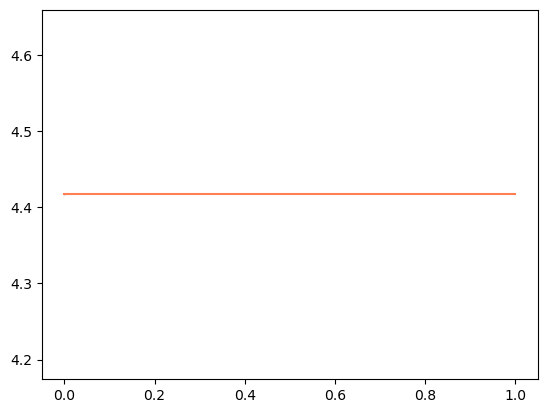

In [248]:
antipode.plotting.plot_loss(losses)

In [45]:
pyro.param('total_counts')

tensor([0.5651, 0.5186, 0.0674, 0.2925, 0.3556, 0.4824, 0.4623, 2.9822, 0.0674,
        0.5989, 0.0674, 0.7375, 0.0674, 0.4290, 0.2837, 0.1669, 0.7157, 1.2267,
        0.6897, 0.0674, 0.4526, 0.3599, 0.2848, 2.5698, 0.9214, 0.9503, 2.8127,
        0.5136, 2.8481, 0.0674, 0.2100, 0.0673, 0.0673, 3.1814, 3.0590, 0.5975,
        0.2607, 0.3978, 0.2647, 0.4844, 3.2429, 0.4805, 0.2449, 0.0674, 0.5471,
        0.0674, 0.0674, 0.7635, 0.1817, 0.4905, 0.2549, 0.3583, 0.4881, 0.3039,
        1.1365, 0.4831, 0.6338, 0.6563, 0.4793, 0.0674, 0.1804, 2.1909, 0.4443,
        0.4745, 0.5940, 1.2016, 1.6893, 0.8370, 0.2414, 0.4956, 0.8878, 0.4020,
        1.1603, 4.4444, 4.4763, 0.2670, 0.1755, 3.5982, 3.3127, 0.3935, 0.0674,
        1.4640, 1.3711, 1.5664, 0.8162, 0.8097, 2.1308, 0.3977, 1.5026, 1.2310,
        0.4015, 0.1638, 0.6581, 0.2644, 0.2641, 0.4830, 0.5395, 2.0155, 0.9351,
        0.2243, 0.4177, 2.5053, 0.4990, 4.1138, 0.1786, 0.0674, 2.0401, 0.5381,
        2.0708, 0.0674, 0.1709, 0.3907, 

In [46]:
toy_model.eval()
latents=[]
clusters=[]
for j in range(0, n_datapoints, batch_size):
    batch = data[j:j+batch_size].to(device)
    latent=toy_model.encoder(batch)
    latents.append(latent[0].cpu().detach().numpy())
    component=toy_model.classifier(latent[0])
    clusters.append(component.cpu().detach().numpy())


In [47]:
adata.obsm['rec_latents']=np.concatenate(latents,axis=0)
adata.obs['rec_clusters']=np.concatenate(clusters,axis=0).argmax(-1)
adata.obs['rec_clusters']=adata.obs['rec_clusters'].astype(str)

In [48]:
out_locs = pyro.param('locs').detach().cpu().numpy()
out_transform_matrix = pyro.param('transform_matrix').detach().cpu().numpy()
out_intercept = pyro.param('intercept').detach().cpu().numpy()
out_total_counts = pyro.param('total_counts').detach().cpu().numpy()

# Compute the learned cluster means
learned_means = out_locs @ out_transform_matrix + out_intercept #+ (out_total_counts**2/2)
learned_means_clusters=[str(x) for x in range(learned_means.shape[0])]
#actual_means = true_params['locs'] @ true_params['transform_matrix'] + true_params['intercept']
actual_means = antipode.model_functions.group_aggr_anndata(adata,['rec_clusters'],normalize=True)
learned_means=learned_means[pd.Series(learned_means_clusters).isin(actual_means[1]['rec_clusters']),:]
actual_means=np.log(actual_means[0]+actual_means[0][actual_means[0]>0].min()*0.9)

100%|██████████| 15/15 [00:00<00:00, 210.20it/s]


In [49]:
zdw_grads=np.absolute(np.stack(grads['transform_matrix'])).mean(0)

ValueError: need at least one array to stack

In [50]:
seaborn.scatterplot(x=actual_means.mean(0),y=np.log(zdw_grads.mean(0)),s=1)
plt.xlabel('var mean')
plt.ylabel('abs gradient')

NameError: name 'zdw_grads' is not defined

In [66]:
mt.running_means

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

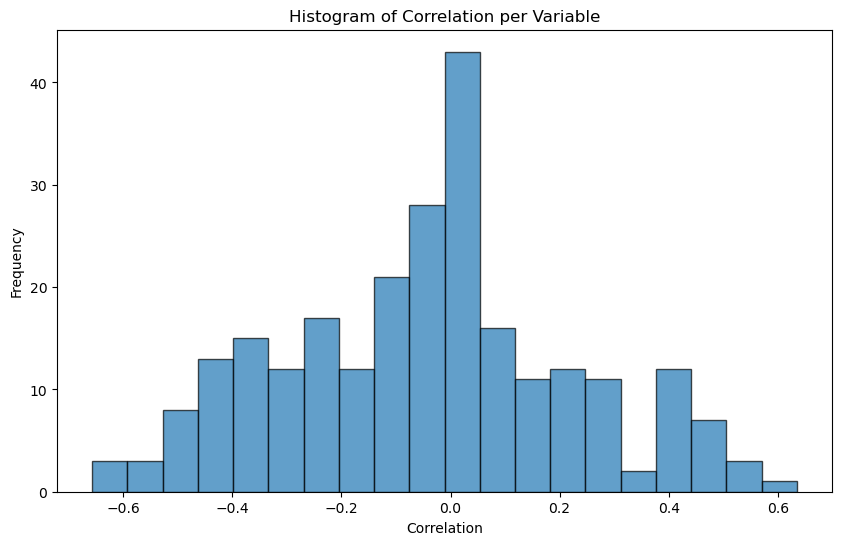

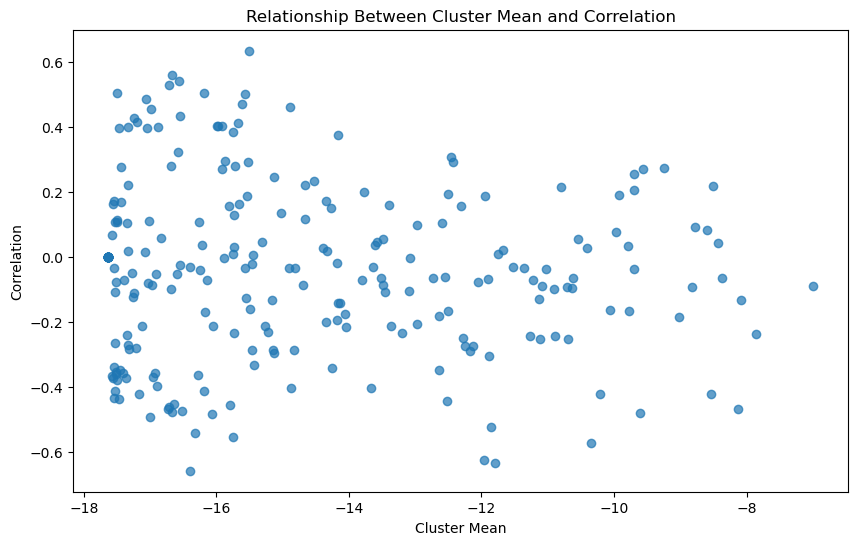

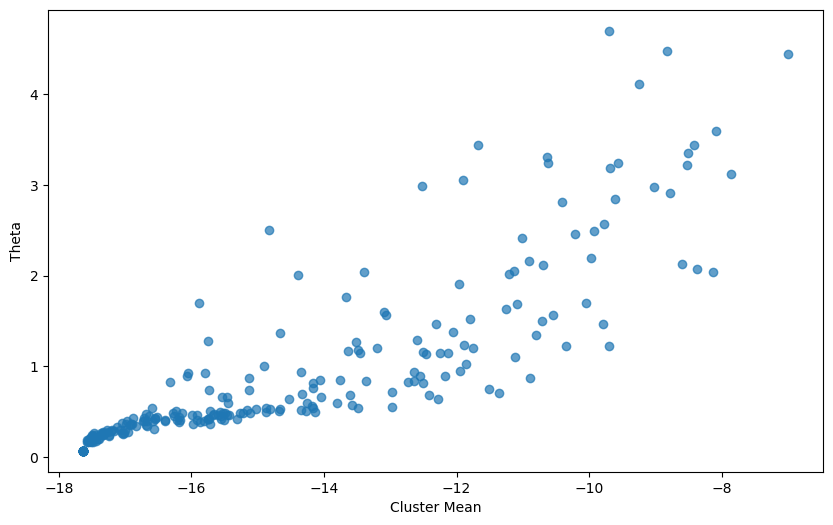

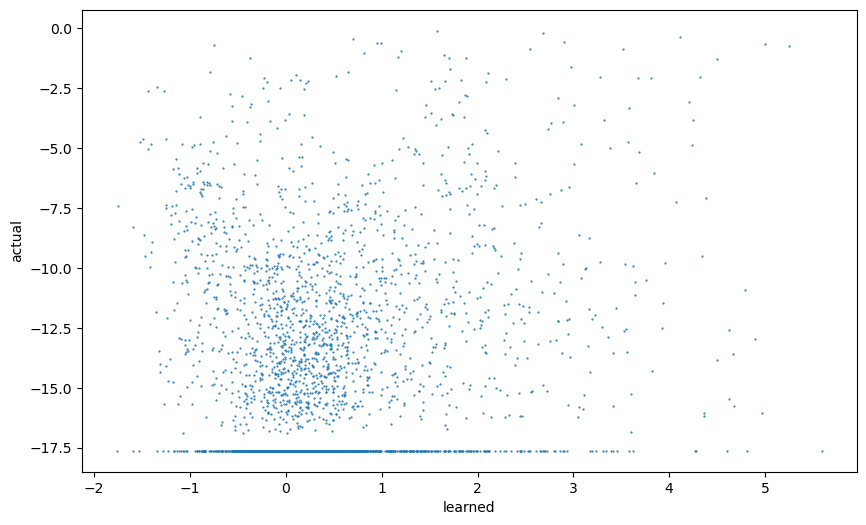

In [51]:
correlations = []
for i in range(toy_model.n_var):
    corr = np.corrcoef(actual_means[:, i], learned_means[:, i])[0, 1]
    correlations.append(corr)

# Plot a histogram of the correlations
plt.figure(figsize=(10, 6))
plt.hist(correlations, bins=20, edgecolor='k', alpha=0.7)
plt.xlabel('Correlation')
plt.ylabel('Frequency')
plt.title('Histogram of Correlation per Variable')
plt.show()

# Plot the relationship between the correlation and the cluster mean
plt.figure(figsize=(10, 6))
plt.scatter(actual_means.mean(axis=0), correlations, alpha=0.7)
plt.xlabel('Cluster Mean')
plt.ylabel('Correlation')
plt.title('Relationship Between Cluster Mean and Correlation')
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(actual_means.mean(axis=0), pyro.param('total_counts').cpu().detach().numpy(), alpha=0.7)
plt.xlabel('Cluster Mean')
plt.ylabel('Theta')
plt.show()


plt.figure(figsize=(10, 6))
plt.scatter(learned_means.flatten(),actual_means.flatten(),s=0.3)
plt.ylabel('actual')
plt.xlabel('learned')
plt.show()


In [52]:
adata.obsm['rec_mde']=scvi.model.utils.mde(adata.obsm['rec_latents'],init='random')
adata.obsm['true_mde']=scvi.model.utils.mde(adata.obsm['true_latents'],init='random')

INFO     Using cuda:0 for `pymde.preserve_neighbors`.                                                              


/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.11 /home/matthew.schmitz/Matthew/utils/miniforge3/e ...


INFO     Using cuda:0 for `pymde.preserve_neighbors`.                                                              


/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.11 /home/matthew.schmitz/Matthew/utils/miniforge3/e ...


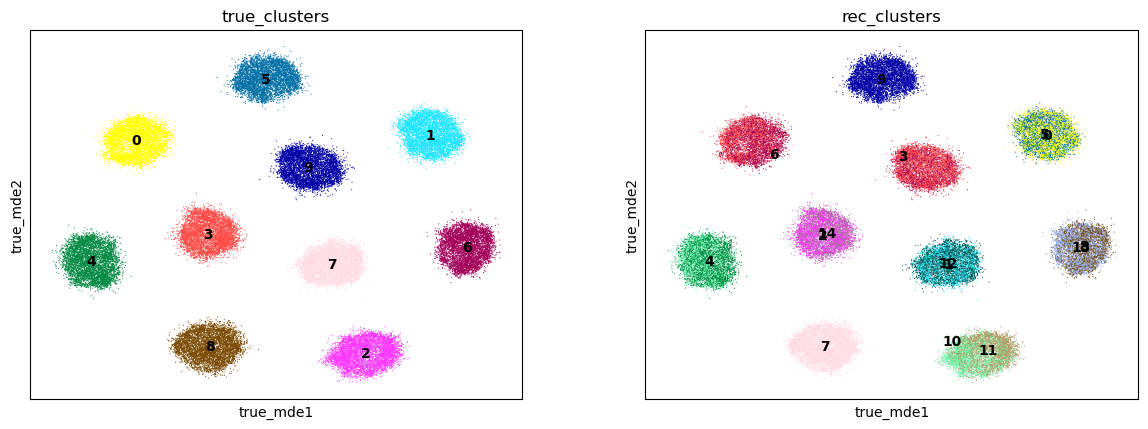

In [53]:
sc.pl.embedding(
    adata,
    basis='true_mde',
    color=['true_clusters','rec_clusters'],
    palette=sc.pl.palettes.godsnot_102,
    legend_loc='on data'
)


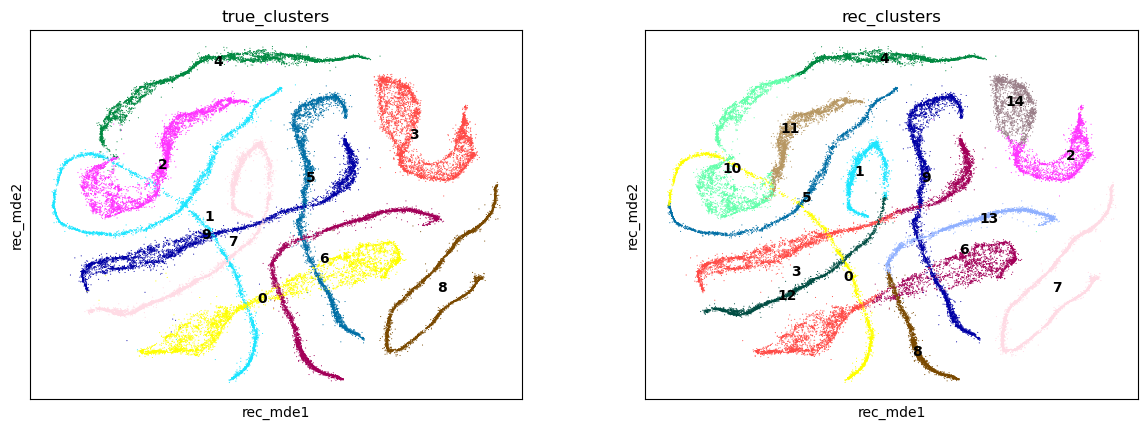

In [54]:
sc.pl.embedding(
    adata,
    basis='rec_mde',
    color=['true_clusters','rec_clusters'],
    palette=sc.pl.palettes.godsnot_102,
    legend_loc='on data'
)

In [112]:
total_counts=1*torch.ones(1)
mus=torch.linspace(-10., 10.,1000).unsqueeze(0)


In [273]:
FlooredLogNormal(loc=torch.zeros(1)+3,scale=1*torch.ones(1),validate_args=False).sample([100000]).mean().log()

tensor(3.4891)

<Axes: ylabel='Count'>

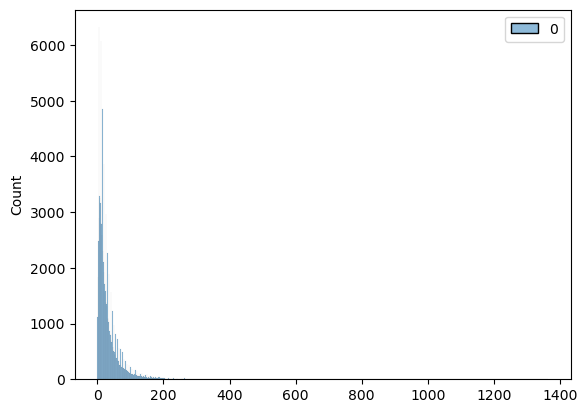

In [271]:
seaborn.histplot(FlooredLogNormal(loc=torch.zeros(1)+3,scale=1*torch.ones(1),validate_args=False).sample([100000]))

In [230]:
FlooredLogNormal(loc=mus,scale=total_counts,validate_args=False).base_dist

Normal(loc: torch.Size([1, 1000]), scale: torch.Size([1, 1000]))

In [115]:
log_probs=FlooredLogNormal(loc=mus,scale=total_counts,validate_args=False).log_prob(torch.cat([mus,mus-1,mus+1,mus.new_zeros(mus.shape)],dim=0).exp())

<Axes: >

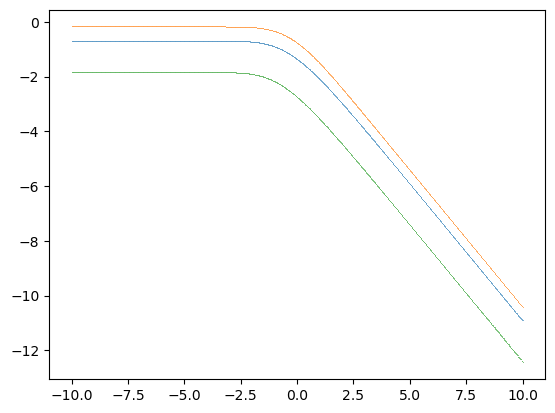

In [116]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=0.5)

<Axes: >

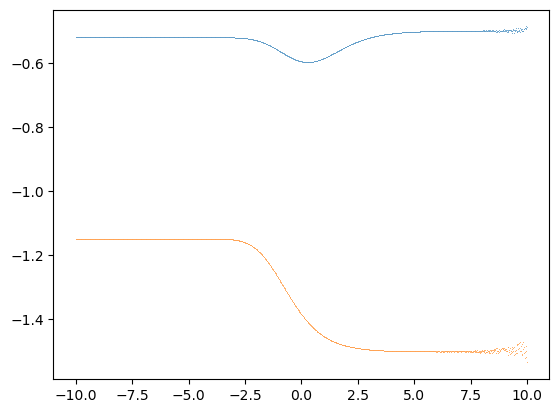

In [117]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[0]-log_probs[1]).numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[2]-log_probs[0]).numpy().flatten(),s=0.5)


<Axes: >

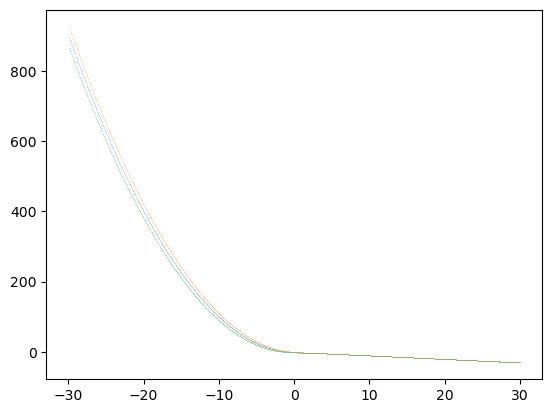

In [17]:
log_probs=dist.NegativeBinomial(total_count=total_counts,logits=mus-total_counts.log(),validate_args=False).log_prob(torch.cat([mus,mus-1,mus+1],dim=0))
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.2)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=0.2)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=0.2)

<Axes: >

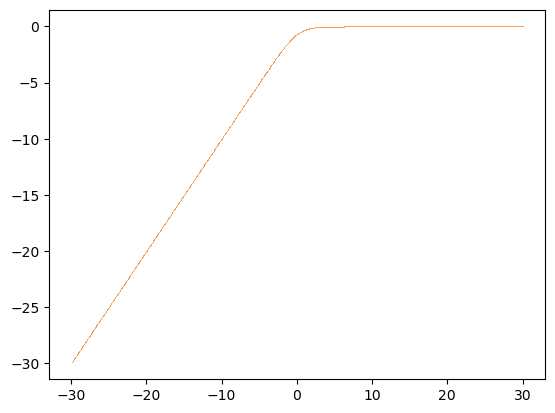

In [18]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[0]-log_probs[1]).numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[2]-log_probs[0]).numpy().flatten(),s=0.5)


In [19]:
total_counts=1*torch.ones(1)
mus=torch.linspace(-30., 30.,1000).unsqueeze(0)
log_probs=dist.NegativeBinomial(total_count=total_counts,probs=total_counts/(mus.exp()+total_counts),validate_args=False).log_prob(torch.cat([mus,mus-1,mus+1],dim=0).exp())

<Axes: >

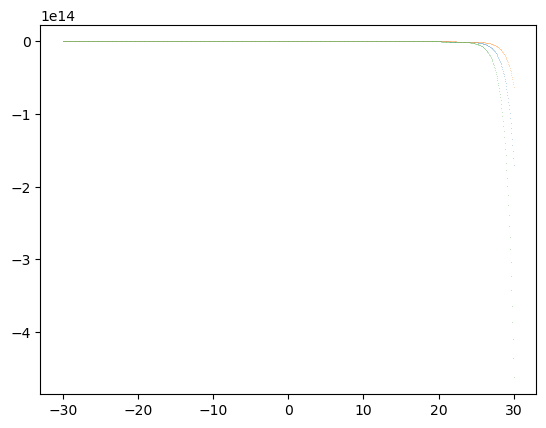

In [20]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.2)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=0.2)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=0.2)

<Axes: >

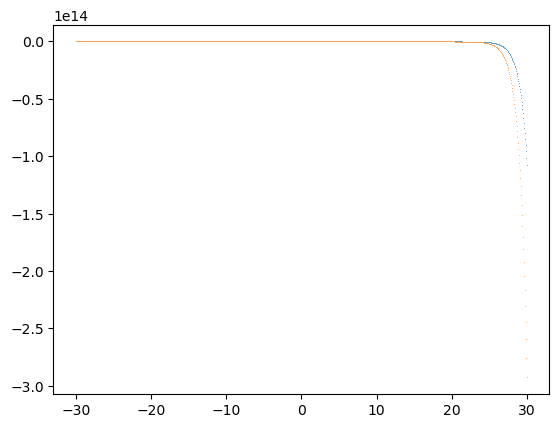

In [21]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[0]-log_probs[1]).numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[2]-log_probs[0]).numpy().flatten(),s=0.5)


In [22]:
log_probs=dist.LogNormal(loc=mus,scale=total_counts,validate_args=False).log_prob(torch.cat([mus,mus-1,mus+1,mus.new_zeros(mus.shape)],dim=0).exp())

<Axes: >

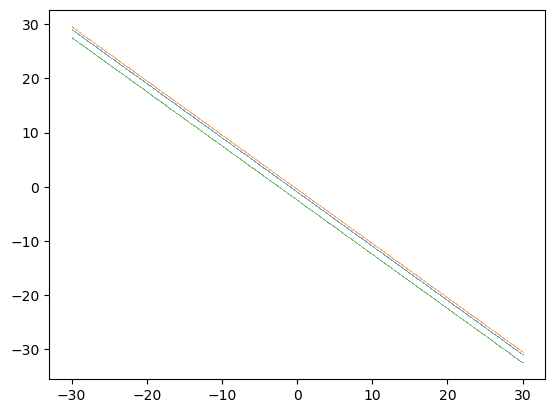

In [23]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=0.5)

<Axes: >

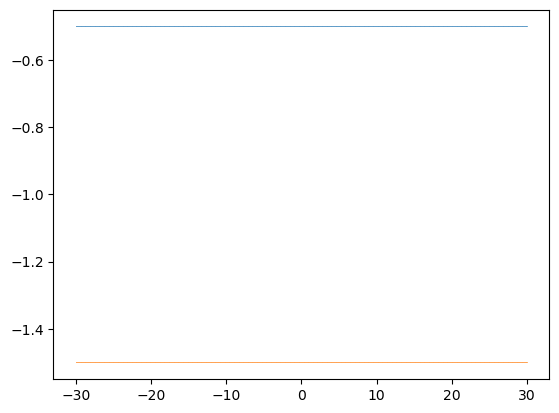

In [24]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[0]-log_probs[1]).numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[2]-log_probs[0]).numpy().flatten(),s=0.5)


In [ ]:
log_probs=dist.RelaxedBernoulli(temperature=0.0001*torch.ones(1),logits=mus,validate_args=False).log_prob(torch.sigmoid(torch.cat([mus,mus-1,mus+1,mus.new_zeros(mus.shape)],dim=0)))

In [ ]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=0.5)

In [ ]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[0]-log_probs[1]).numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[2]-log_probs[0]).numpy().flatten(),s=0.5)

In [ ]:
log_probs=dist.Bernoulli(logits=mus,validate_args=False).log_prob(torch.sigmoid(torch.cat([mus,mus-1,mus+1,mus.new_zeros(mus.shape)],dim=0)))

In [ ]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=0.5)

In [ ]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[0]-log_probs[1]).numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[2]-log_probs[0]).numpy().flatten(),s=0.5)

In [ ]:
seaborn.heatmap(log_probs.numpy())

<Axes: >

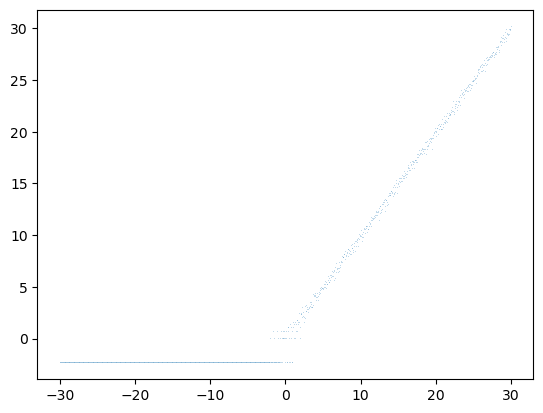

In [29]:
total_counts=10*torch.ones(1)
mus=torch.linspace(-30., 30.,1000).unsqueeze(0)
nb_outs=dist.NegativeBinomial(total_count=total_counts,logits=mus-total_counts.log(),validate_args=False).sample()
seaborn.scatterplot(x=mus.numpy().flatten(),y=np.log(nb_outs.numpy().flatten()+1e-1),s=0.2)

<Axes: >

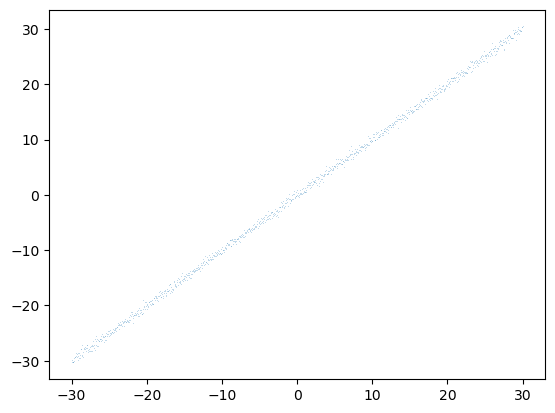

In [32]:
ln_outs=dist.LogNormal(loc=mus,scale=5/total_counts,validate_args=False).sample()
seaborn.scatterplot(x=mus.numpy().flatten(),y=np.log(ln_outs.numpy().flatten()+1e-15),s=0.2)